# Adaptive AM-FM Decomposition of Speech for Parkinson’s Disease Classification
## Support Vector Machine (SVM) Classification Pipeline using the NeuroVoz Dataset

### Notebook Overview
This notebook implements a machine learning pipeline to distinguish between individuals with **Parkinson's Disease (PD)** and **Healthy Controls (HC)** based on acoustic features extracted from vowel phonations (/a/, /e/, /i/, /o/, /u/). 

The analysis focuses on high-frequency resolution features, specifically exploring variations in the first five harmonics ($H_1$ through $H_5$) derived from a high-resolution sinusoidal model named **eaQHM**, to identify potential vocal biomarkers associated with the pathology.

### Data Processing & Methodology
1.  **Data Ingestion:** Loading raw acoustic results from MATLAB (`.mat`) and merging with external subject metadata.
2.  **Feature Engineering:** Unpacking nested harmonic amplitude and frequency variation vectors into discrete scalar features.
3.  **Imputation & Cleaning:** Manual handling of missing demographic data and string normalization for phonetic identifiers.
4.  **Validation:** Multi-layered audits to ensure label consistency and speaker-independent integrity.
5.  **Model Training:** A **Repeated Nested Speaker-Independent Cross-Validation** (10x5 stratified) approach using a **Random Forest Classifier** to ensure robust performance estimates.
6.  **Evaluation:** Analyzing results at both the **Sample Level** (individual recordings) and **Subject Level** (aggregated speaker diagnosis), alongside **Permutation Importance** for feature interpretability.

### Data Ingestion and Feature Engineering

In [ ]:
import pandas as pd
from scipy.io import loadmat

data = loadmat('neurovoz_paper.mat')

data_aeiou = data['results'].squeeze()
data_aeiou = pd.DataFrame(data_aeiou)
data_aeiou.columns=['centroid_mean', 'centroid_std', 'spectral_flux_mean', 'spectral_flux_max', 'teo_mean', 'teo_std', 'am_fm_corr', 'ampl_var', 'freq_var', 'f0_var', 'SRER', 
                    'jitter', 'jitter_T', 'shimmer', 'spectral_slope', 'f0_entropy', 'name']
file_names = data_aeiou['name'].apply(lambda x: x[0])

data = data_aeiou

# Expand ampl_var and freq_var into separate harmonics
ampl_expanded = data['ampl_var'].apply(lambda x: x.flatten())
freq_expanded = data['freq_var'].apply(lambda x: x.flatten())

data['centroid_mean'] = data['centroid_mean'].apply(lambda x: x[0][0])
data['centroid_std']  = data['centroid_std'].apply(lambda x: x[0][0])
data['spectral_flux_mean'] = data['spectral_flux_mean'].apply(lambda x: x[0][0])
data['spectral_flux_max']  = data['spectral_flux_max'].apply(lambda x: x[0][0])
data['teo_mean']  = data['teo_mean'].apply(lambda x: x[0][0])
data['teo_std']   = data['teo_std'].apply(lambda x: x[0][0])
data['am_fm_corr'] = data['am_fm_corr'].apply(lambda x: x[0][0])

data['f0_var']   = data['f0_var'].apply(lambda x: x[0][0])
data['SRER']     = data['SRER'].apply(lambda x: x[0][0])
data['jitter']   = data['jitter'].apply(lambda x: x[0][0])
data['jitter_T'] = data['jitter_T'].apply(lambda x: x[0][0])
data['shimmer']  = data['shimmer'].apply(lambda x: x[0][0])
data['spectral_slope'] = data['spectral_slope'].apply(lambda x: x[0][0])
data['f0_entropy'] = data['f0_entropy'].apply(lambda x: x[0][0])

# Split the filename into its 3 components: ['HC', 'U2', '0135']
filename_parts = file_names.str.split('_')

# Assign label based on the first part (Group): PD = 1 (pathological), HC = 0 (control)
data['label'] = filename_parts.str[0].map({'PD': 1, 'HC': 0})

# Extract the 4-digit speaker ID (the third part of the filename)
data['speaker'] = filename_parts.str[2] 

# Load the new metadata CSVs
metadata_hc = pd.read_csv("metadata_hc.csv")
metadata_pd = pd.read_csv("metadata_pd.csv")

# Combine HC and PD metadata, keeping only the 'ID' and 'Sex' columns
gender_data = pd.concat([metadata_hc[['ID', 'Sex']], metadata_pd[['ID', 'Sex']]])

# Drop missing values and duplicates (since each speaker has multiple audio rows)
gender_data = gender_data.dropna(subset=['Sex']).drop_duplicates()

# Rename columns to match what the rest of your code expects
gender_data = gender_data.rename(columns={'ID': 'speaker', 'Sex': 'gender'})

# Convert the integer ID to a 4-digit string to match the extracted '0135', '0004' format
gender_data['speaker'] = gender_data['speaker'].astype(int).astype(str).str.zfill(4)

# Convert gender from float (1.0 / 0.0) to standard integer (1 / 0)
gender_data['gender'] = gender_data['gender'].astype(int)

# Ensure 'speaker' is a string in the main dataframe as well
data['speaker'] = data['speaker'].astype(str)

# Merge the dataframes together based on 'speaker'
data = data.merge(gender_data, how="left", on="speaker")

# Drop unused features
data = data.drop(columns=['jitter_T', 'ampl_var', 'freq_var', 'am_fm_corr', 'f0_entropy', 'f0_var', 'SRER']) 

### Harmonic Feature Expansion

In [ ]:
for i in range(5):
    data[f'ampl_var_H{i+1}'] = ampl_expanded.apply(lambda v: v[i])

for i in range(5):
    data[f'freq_var_H{i+1}'] = freq_expanded.apply(lambda v: v[i])
    
print(data.head())
print(data.shape)
print(data.info())

   centroid_mean  centroid_std  spectral_flux_mean  spectral_flux_max  \
0     370.712404     18.498518            0.000003           0.000020   
1     580.567088     16.454154            0.000003           0.000010   
2     190.197134      8.915104            0.000002           0.000011   
3     302.635175      9.495738            0.000002           0.000005   
4     630.107766     17.854114            0.000001           0.000016   

   teo_mean   teo_std    jitter   shimmer  spectral_slope          name  ...  \
0  3.661109  0.539809  0.000286  0.000048       -0.346980  [HC_A1_0034]  ...   
1  4.251770  0.267069  0.000100  0.000050       -0.274792  [HC_A1_0036]  ...   
2 -0.484863  0.244631  0.000156  0.000392       -0.449712  [HC_A1_0045]  ...   
3  2.061750  0.341312  0.000099  0.000279       -0.226498  [HC_A1_0048]  ...   
4  3.710253  0.222105  0.000151  0.000147        0.106426  [HC_A1_0049]  ...   

   ampl_var_H1 ampl_var_H2  ampl_var_H3  ampl_var_H4  ampl_var_H5  \
0     0.121

### Gender Column Cleanup and Imputation

In [ ]:
# Identify which speaker IDs failed the merge
missing_speakers = data[data['gender'].isna()]['speaker'].unique()

# 0068 -> FEMALE
# 0069 -> FEMALE
# 0084 -> FEMALE
# 0121 -> MALE
# 0059 -> FEMALE

print(f"Found {len(missing_speakers)} speakers missing gender info:")
print(missing_speakers)

# missing speakers and their corresponding gender (Female=0, Male=1)
manual_genders = {
    '0068': 0,
    '0069': 0,
    '0084': 0,
    '0121': 1,
    '0059': 0
}

# We map the 'speaker' column to our dictionary, and use fillna to only replace the NaNs
data['gender'] = data['gender'].fillna(data['speaker'].map(manual_genders))

data['gender'] = data['gender'].astype(int)

print("Remaining missing genders:", data['gender'].isna().sum())
print("Gender column data type:", data['gender'].dtype)

print(data.info())

Found 5 speakers missing gender info:
['0068' '0069' '0084' '0121' '0059']
Remaining missing genders: 0
Gender column data type: int32
<class 'pandas.core.frame.DataFrame'>
Int64Index: 1066 entries, 0 to 1065
Data columns (total 23 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   centroid_mean       1066 non-null   float64
 1   centroid_std        1066 non-null   float64
 2   spectral_flux_mean  1066 non-null   float64
 3   spectral_flux_max   1066 non-null   float64
 4   teo_mean            1066 non-null   float64
 5   teo_std             1066 non-null   float64
 6   jitter              1066 non-null   float64
 7   shimmer             1066 non-null   float64
 8   spectral_slope      1066 non-null   float64
 9   name                1066 non-null   object 
 10  label               1066 non-null   int64  
 11  speaker             1066 non-null   object 
 12  gender              1066 non-null   int32  
 13  ampl_var_H1       

### Data Integrity and Label Validation

In [ ]:
# Extract the group prefix ('PD' or 'HC') directly from the original filenames
group_prefix = file_names.str.split('_').str[0]
expected_label = group_prefix.map({'PD': 1, 'HC': 0})

# Check for mismatches between expected and actual
incorrect = data.loc[data['label'] != expected_label, ['speaker', 'label']]

if incorrect.empty:
    print("All labels are correct according to the filename prefix.")
else:
    print("Incorrectly labeled speakers found:")
    print(incorrect.drop_duplicates())

# Check for consistency: each speaker should have exactly one label
speaker_labels = data.groupby('speaker')['label'].nunique()
bad_speakers = speaker_labels[speaker_labels > 1]

if bad_speakers.empty:
    print("No speaker has inconsistent labels.")
else:
    print("Speakers with inconsistent labels:")
    print(bad_speakers)
    
# Count total gender distribution
print("Total gender distribution (0=Female, 1=Male):")
print(data[['speaker', 'gender']].drop_duplicates()['gender'].value_counts())

# Count per group (PD=1 vs HC=0)
print("\nGender distribution per group:")
print(data[['speaker', 'gender', 'label']].drop_duplicates().groupby(['label', 'gender']).size())

print("\nClass Distribution")
print(data['label'].value_counts())

✅ All labels are correct according to the filename prefix.
✅ No speaker has inconsistent labels.
Total gender distribution (0=Female, 1=Male):
1    61
0    50
Name: gender, dtype: int64

Gender distribution per group:
label  gender
0      0         29
       1         29
1      0         21
       1         32
dtype: int64

Class Distribution
1    565
0    501
Name: label, dtype: int64


### Vowel Extraction and Sample Distribution

In [ ]:
# Clean the 'name' column so it contains pure strings instead of arrays/lists
data['name'] = data['name'].apply(lambda x: str(x[0]) if not isinstance(x, str) else str(x))

# Extract the vowel from the 'name' column
data['vowel'] = data['name'].str.split('_').str[1].str[0].str.upper()

# Calculate the number of samples for each vowel
vowel_counts = data['vowel'].value_counts()

print("Number of samples per vowel:")
print(vowel_counts)

print("\nBreakdown of vowels by group (1=PD, 0=HC):")
print(data.groupby(['label', 'vowel']).size())

Number of samples per vowel:
A    250
O    240
I    237
E    204
U    135
Name: vowel, dtype: int64

Breakdown of vowels by group (1=PD, 0=HC):
label  vowel
0      A        116
       E         83
       I        106
       O        115
       U         81
1      A        134
       E        121
       I        131
       O        125
       U         54
dtype: int64


### Final Preparation for Machine Learning

In [ ]:
# Shuffle the data (optional)
random_state = 42

data = data.sample(frac=1, random_state=42).reset_index(drop=True)

groups = data['speaker']
print(len(groups.unique()), 'unique groups found.')
    
data = data.drop(columns=['speaker', 'name', 'vowel'])

print('Data shape:', data.shape)
print(data.head())
print(data.tail())

total_nans = data.isna().sum().sum()
print("Total NaNs in dataset:", total_nans)

print("NaNs per column:")
print(data.isna().sum())

111 unique groups found.
Checking alignment between 'groups' variable and 'data' dataframe...
Total Rows: 1066
Mismatches found: 0
✅ Data appears aligned (Unexpected if you shuffled one but not the other).
Data shape: (1066, 21)
   centroid_mean  centroid_std  spectral_flux_mean  spectral_flux_max  \
0     391.368917     19.125601            0.000002           0.000009   
1     290.915706      5.089947            0.000002           0.000010   
2     443.217160     10.838963            0.000003           0.000014   
3     260.899793      6.506913            0.000002           0.000015   
4     234.594065     11.779240            0.000009           0.000059   

   teo_mean   teo_std    jitter   shimmer  spectral_slope  label  ...  \
0  2.790702  0.499818  0.000126  0.000142       -0.240521      0  ...   
1  4.375209  0.465465  0.000559  0.000048       -1.293117      1  ...   
2  5.473562  0.393835  0.000311  0.000127       -0.157774      0  ...   
3  1.666918  0.366216  0.000214  0.00029

### Repeated, 10-by-5 stratified (by gender and label) speaker-independent nested cross-validation

In [ ]:
import pandas as pd
import numpy as np
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedGroupKFold, GridSearchCV
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix, precision_score, recall_score
from sklearn.inspection import permutation_importance
from typing import Tuple


def aggregate_mean_by_group(y: np.ndarray, p: np.ndarray, g: np.ndarray) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Aggregate probabilities per speaker by mean. Speaker label is majority vote."""
    y = np.asarray(y).astype(int)
    p = np.asarray(p).astype(float)
    g = np.asarray(g)
    uniq = np.unique(g)
    y_g = np.zeros(len(uniq), dtype=int)
    p_g = np.zeros(len(uniq), dtype=float)

    for i, gg in enumerate(uniq):
        idx = np.where(g == gg)[0]
        p_g[i] = float(np.mean(p[idx])) if len(idx) else float('nan')
        # Using >= 0.5 for majority vote on the ground truth label per speaker
        y_g[i] = int(np.mean(y[idx]) >= 0.5) if len(idx) else 0

    return y_g, p_g, uniq

data['stratify_key'] = data['label'].astype(str) + "_" + data['gender'].astype(str)

X = data.drop(columns=['label', 'gender', 'stratify_key'])
y = data['label']
y_stratify = data['stratify_key']

# CONFIGURATION
N_REPEATS = 5  
N_OUTTER_SPLITS = 10   
N_INNER_SPLITS = 5
base_random_state = 42

# --- Storage for Results ---
metrics_template = {"accuracy": [], "f1": [], "auc": [], "precision": [], "recall": []}

results_sample = {k: [] for k in metrics_template}
results_speaker = {k: [] for k in metrics_template}

conf_matrices_sample = []
conf_matrices_speaker = []
all_perm_importances = [] 

print(f"Starting SVM Repeated Nested CV ({N_REPEATS} Repeats x {N_OUTTER_SPLITS} Folds)...")

for repeat in range(N_REPEATS):
    current_seed = base_random_state + repeat
    print(f"\n" + "="*85)
    print(f"REPEAT {repeat + 1}/{N_REPEATS} (Seed: {current_seed})")
    print("="*85)

    outer_cv = StratifiedGroupKFold(n_splits=N_OUTTER_SPLITS, shuffle=True, random_state=current_seed)
    inner_cv = StratifiedGroupKFold(n_splits=N_INNER_SPLITS, shuffle=True, random_state=current_seed)

    svm_pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('svc', SVC(probability=True, random_state=current_seed, class_weight='balanced'))
    ])

    param_grid = {
        "svc__C": [0.001, 0.01, 0.1, 1, 10, 100, 1000],
        "svc__gamma": ['scale', 'auto', 1, 0.1, 0.01, 0.001, 0.0001],
        "svc__kernel": ['rbf'] 
    }
    
    for fold, (train_idx, test_idx) in enumerate(outer_cv.split(X, y_stratify, groups)):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        y_strat_train = y_stratify.iloc[train_idx]
        g_train, g_test = groups[train_idx], groups[test_idx]

        grid_search = GridSearchCV(
            estimator=svm_pipe,
            param_grid=param_grid,
            cv=list(inner_cv.split(X_train, y_strat_train, g_train)),
            scoring="roc_auc",
            n_jobs=-1,
            verbose=0
        )
        grid_search.fit(X_train, y_train)
        best_model = grid_search.best_estimator_

        best_params = best_model.named_steps['svc'].get_params()
        best_C = best_params['C']
        best_gamma = best_params['gamma']
        best_kernel = best_params['kernel']

        # SAMPLE-LEVEL Predictions
        y_pred_sample = best_model.predict(X_test)
        y_proba_sample = best_model.predict_proba(X_test)[:, 1]

        results_sample["accuracy"].append(accuracy_score(y_test, y_pred_sample))
        results_sample["f1"].append(f1_score(y_test, y_pred_sample, zero_division=0))
        results_sample["auc"].append(roc_auc_score(y_test, y_proba_sample))
        results_sample["precision"].append(precision_score(y_test, y_pred_sample, zero_division=0))
        results_sample["recall"].append(recall_score(y_test, y_pred_sample, zero_division=0))
        conf_matrices_sample.append(confusion_matrix(y_test, y_pred_sample))

        # SPEAKER-LEVEL Predictions
        y_test_spk, y_proba_spk, speakers = aggregate_mean_by_group(y_test, y_proba_sample, g_test)
        y_pred_spk = (y_proba_spk >= 0.5).astype(int)

        results_speaker["accuracy"].append(accuracy_score(y_test_spk, y_pred_spk))
        results_speaker["f1"].append(f1_score(y_test_spk, y_pred_spk, zero_division=0))
        results_speaker["auc"].append(roc_auc_score(y_test_spk, y_proba_spk))            
        results_speaker["precision"].append(precision_score(y_test_spk, y_pred_spk, zero_division=0))
        results_speaker["recall"].append(recall_score(y_test_spk, y_pred_spk, zero_division=0))
        conf_matrices_speaker.append(confusion_matrix(y_test_spk, y_pred_spk))

        print(f"R{repeat+1} Fold {fold+1}: C={best_C}, Gamma={best_gamma}, Kernel={best_kernel}")
        print(f"   [Sample]  Acc: {results_sample['accuracy'][-1]:.3f} | F1: {results_sample['f1'][-1]:.3f} | AUC: {results_sample['auc'][-1]:.3f} | Prec: {results_sample['precision'][-1]:.3f} | Rec: {results_sample['recall'][-1]:.3f}")
        print(f"   [Speaker] Acc: {results_speaker['accuracy'][-1]:.3f} | F1: {results_speaker['f1'][-1]:.3f} | AUC: {results_speaker['auc'][-1]:.3f} | Prec: {results_speaker['precision'][-1]:.3f} | Rec: {results_speaker['recall'][-1]:.3f}")
        print("-" * 85)

        perm_result = permutation_importance(
            estimator=best_model,
            X=X_test,
            y=y_test,
            scoring='roc_auc',
            n_repeats=5,
            random_state=current_seed,
            n_jobs=-1
        )

        perm_df = pd.DataFrame({
            "feature": X_test.columns,
            "importance_mean": perm_result.importances_mean,
            "fold": (repeat * N_OUTTER_SPLITS) + fold + 1
        })
        all_perm_importances.append(perm_df)


print("\n" + "="*70)
print(f"FINAL SVM AGGREGATED RESULTS ({N_REPEATS * N_OUTTER_SPLITS} Total Folds)")
print("="*70)
print(f"{'Metric':<12} | {'Sample-Level (Mean ± STD)':<25} | {'Speaker-Level (Mean ± STD)':<25}")
print("-" * 70)

for metric in metrics_template.keys():
    mean_samp = np.nanmean(results_sample[metric])
    std_samp = np.nanstd(results_sample[metric])
    mean_spk = np.nanmean(results_speaker[metric])
    std_spk = np.nanstd(results_speaker[metric])
    
    print(f"{metric.capitalize():<12} | {mean_samp:.4f} ± {std_samp:.4f}           | {mean_spk:.4f} ± {std_spk:.4f}")
vowel_counts = data_aeiou['vowel'].value_counts()

# Feature Importance
perm_importances_df = pd.concat(all_perm_importances, axis=0)
final_perm_importance = perm_importances_df.groupby('feature')['importance_mean'].agg(['mean', 'std']).sort_values(by='mean', ascending=False)
print("\n--- Top 10 Features (Mean Decrease in AUC) ---")
print(final_perm_importance.head(10))

Starting SVM Repeated Nested CV (5 Repeats x 10 Folds)...

REPEAT 1/5 (Seed: 42)
R1 Fold 1: C=10, Gamma=0.01, Kernel=rbf
   [Sample]  Acc: 0.593 | F1: 0.531 | AUC: 0.652 | Prec: 0.634 | Rec: 0.456
   [Speaker] Acc: 0.455 | F1: 0.400 | AUC: 0.667 | Prec: 0.400 | Rec: 0.400
-------------------------------------------------------------------------------------
R1 Fold 2: C=1000, Gamma=0.001, Kernel=rbf
   [Sample]  Acc: 0.589 | F1: 0.585 | AUC: 0.642 | Prec: 0.585 | Rec: 0.585
   [Speaker] Acc: 0.545 | F1: 0.615 | AUC: 0.700 | Prec: 0.500 | Rec: 0.800
-------------------------------------------------------------------------------------
R1 Fold 3: C=1000, Gamma=0.001, Kernel=rbf
   [Sample]  Acc: 0.718 | F1: 0.805 | AUC: 0.806 | Prec: 0.938 | Rec: 0.706
   [Speaker] Acc: 0.727 | F1: 0.824 | AUC: 0.778 | Prec: 0.875 | Rec: 0.778
-------------------------------------------------------------------------------------
R1 Fold 4: C=1000, Gamma=0.0001, Kernel=rbf
   [Sample]  Acc: 0.437 | F1: 0.310

### Performance Evaluation and Feature Interpretability

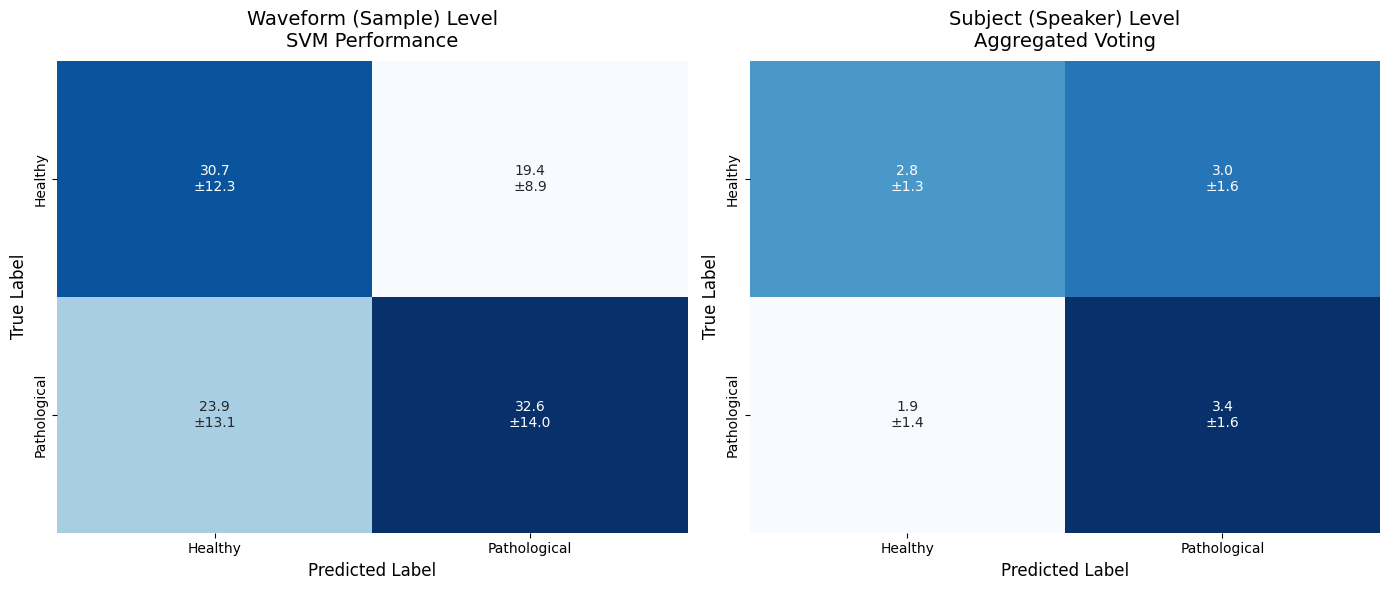

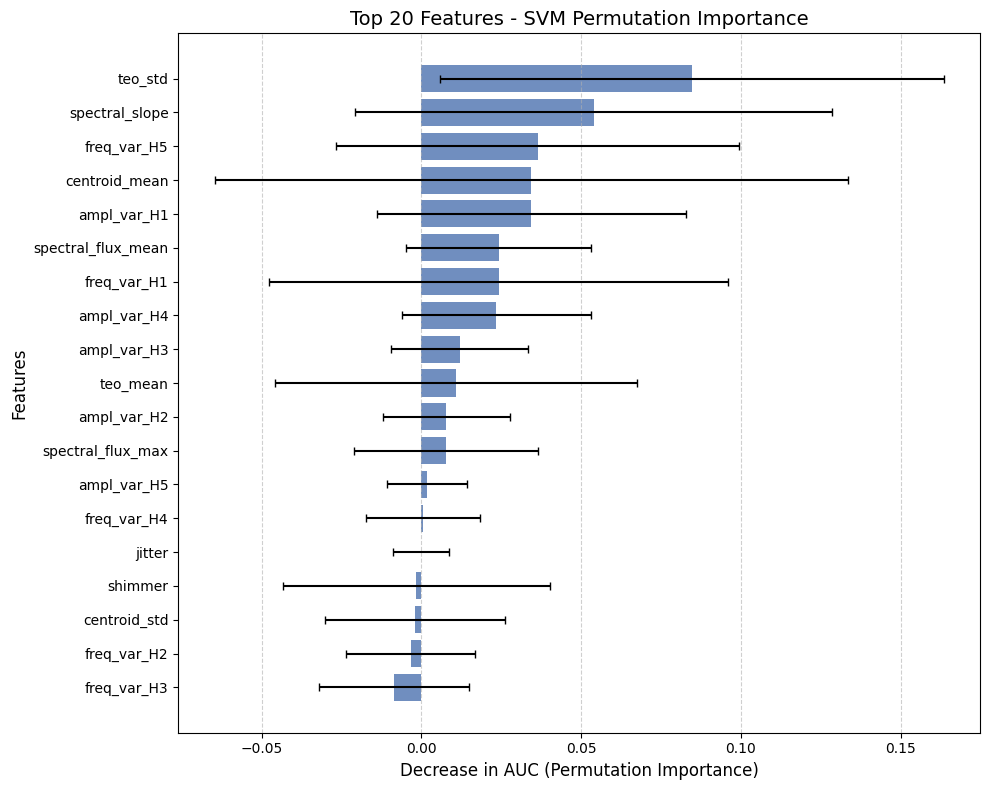

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


def plot_cm(cm_list, title, ax):
    cms = np.array(cm_list)
    mean_cm = np.mean(cms, axis=0)
    std_cm = np.std(cms, axis=0)
    
    annot = np.empty_like(mean_cm).astype(str)
    for i in range(mean_cm.shape[0]):
        for j in range(mean_cm.shape[1]):
            annot[i, j] = f"{mean_cm[i, j]:.1f}\n±{std_cm[i, j]:.1f}"
            
    sns.heatmap(mean_cm, annot=annot, fmt='', cmap='Blues', cbar=False, 
                xticklabels=['Healthy', 'Pathological'], 
                yticklabels=['Healthy', 'Pathological'], ax=ax)
    
    ax.set_title(title, fontsize=14, pad=10)
    ax.set_xlabel('Predicted Label', fontsize=12)
    ax.set_ylabel('True Label', fontsize=12)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

if len(conf_matrices_sample) > 0:
    plot_cm(conf_matrices_sample, 'Waveform (Sample) Level\nSVM Performance', axes[0])
else:
    axes[0].text(0.5, 0.5, 'No Data', ha='center')

if len(conf_matrices_speaker) > 0:
    plot_cm(conf_matrices_speaker, 'Subject (Speaker) Level\nAggregated Voting', axes[1])
else:
    axes[1].text(0.5, 0.5, 'No Data', ha='center')

plt.tight_layout()
plt.show()

if 'final_perm_importance' in locals():
    plot_data = final_perm_importance.head(20).sort_values(by='mean', ascending=True)

    plt.figure(figsize=(10, 8))
    plt.barh(
        plot_data.index,
        plot_data['mean'],
        xerr=plot_data['std'], 
        align='center',
        alpha=0.8,
        color='#4c72b0',
        ecolor='black',
        capsize=3
    )
    plt.xlabel("Decrease in AUC (Permutation Importance)", fontsize=12)
    plt.ylabel("Features", fontsize=12)
    plt.title("Top 20 Features - SVM Permutation Importance", fontsize=14)
    plt.grid(axis='x', linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()
else:
    print("Feature importance data not found. Run the SVM analysis first.")